# Notebook 02: EDA, missingness and leakage-safe features

**Objective:** Understand the data using dev rows only, resolve the open data-quality questions from Notebook 01, and build one feature definition for all models.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

df = pd.read_parquet("../data/interim/merged_with_split.parquet")
audit = pd.read_csv("../reports/tables/leakage_candidates.csv")

targets = ["adverse_outcome", "readmission_30d"]

dev = df[df["split"] == "dev"].copy()
val = df[df["split"] == "val"].copy()
holdout_x = df[df["split"] == "holdout"].drop(columns=targets)  # labels removed on purpose
del df

print("dev:", dev.shape, "| val:", val.shape, "| holdout (features only):", holdout_x.shape)
print("Holdout has target columns:", any(t in holdout_x.columns for t in targets))
print(audit["status"].value_counts().to_dict())

dev: (400365, 138) | val: (133853, 138) | holdout (features only): (265782, 136)
Holdout has target columns: False
{'ALLOW': 71, 'LAB': 30, 'EXCLUDE': 24, 'VERIFY': 4, 'BOOKKEEPING': 4, 'REGIME_ONLY': 3, 'TARGET': 2}


In [2]:
print(dev.groupby("arrival_year")["annual_ed_volume"].agg(["mean", "std", "min", "max"]).round(0))
print()

print(dev.groupby("bed_count_category")["annual_ed_volume"].agg(["min", "max", "mean"]).round(0))
print()

print(dev.groupby("hospital_type")["annual_ed_volume"].agg(["min", "max", "mean"]).round(0))
print()

grp = dev.groupby(["city", "hospital_type"])["annual_ed_volume"]
cv = (grp.std() / grp.mean()).median()
print("Median CV within city + hospital_type:", round(float(cv), 3))
print()

keys = ["city", "hospital_type", "arrival_year"]
rows = dev.groupby(keys).size().rename("rows")
vol = dev.groupby(keys)["annual_ed_volume"].mean().rename("mean_volume")
print("Corr(rows per city-type-year, mean annual_ed_volume):", round(rows.corr(vol), 3))
print()

print(dev[["annual_ed_volume"] + targets].corr().round(3))

                  mean      std    min     max
arrival_year                                  
2019          130299.0  87426.0  10000  534110
2020          129579.0  86782.0  10000  549717
2021          130322.0  87490.0  10000  542493

                            min     max      mean
bed_count_category                               
Primary (<100k/yr)        10000  100000   67918.0
Secondary (100-200k/yr)  100001  200000  136959.0
Tertiary (>200k/yr)      200002  549717  318010.0

                                   min     max      mean
hospital_type                                           
City Hospital                   146079  549717  349635.0
Private Hospital                 10000  116874   49969.0
State Hospital                   20000  199741   90016.0
Training and Research Hospital   30000  329137  159916.0
University Hospital              30000  257609  129824.0

Median CV within city + hospital_type: 0.25

Corr(rows per city-type-year, mean annual_ed_volume): -0.167

      

In [3]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

vitals = ["heart_rate_bpm", "sbp_mmhg", "dbp_mmhg", "map_mmhg", "respiratory_rate_rpm",
          "temperature_celsius", "spo2_pct", "gcs_total", "pain_score_nrs"]
labs = audit.loc[audit["status"] == "LAB", "column"].tolist()
excl_num = [c for c in audit.loc[audit["status"] == "EXCLUDE", "column"]
            if pd.api.types.is_numeric_dtype(dev[c])]
print("vitals:", len(vitals), "| labs:", len(labs), "| excluded numeric:", len(excl_num))

samp = dev.sample(100_000, random_state=42)
sets = {"1_vitals": vitals,
        "2_vitals+labs": vitals + labs,
        "3_vitals+labs+excluded": vitals + labs + excl_num}

rows = []
for score in ["mews_score", "news2_score", "sofa_score_approx"]:
    for name, cols in sets.items():
        Xtr, Xte, ytr, yte = train_test_split(samp[cols], samp[score], test_size=0.3, random_state=42)
        m = HistGradientBoostingRegressor(max_iter=100, random_state=42).fit(Xtr, ytr)
        rows.append((score, name, round(r2_score(yte, m.predict(Xte)), 3)))

print(pd.DataFrame(rows, columns=["score", "inputs", "R2"])
        .pivot(index="score", columns="inputs", values="R2"))

vitals: 9 | labs: 30 | excluded numeric: 20


C:\Users\Softmgmt\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Softmgmt\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Softmgmt\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Softmgmt\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^

inputs             1_vitals  2_vitals+labs  3_vitals+labs+excluded
score                                                             
mews_score            1.000          1.000                   1.000
news2_score           0.999          0.999                   0.999
sofa_score_approx     0.828          1.000                   1.000


In [4]:
upd = {
    "annual_ed_volume":   ("ALLOW", "hospital-size proxy; per-row draw by hospital type"),
    "mews_score":         ("ALLOW", "function of vitals (R2 1.000)"),
    "news2_score":        ("ALLOW", "function of vitals (R2 0.999)"),
    "sofa_score_approx":  ("LAB", "function of vitals + labs (R2 1.000); dropped in no-labs ablation"),
    "bed_count_category": ("DROP_REDUNDANT", "binned copy of annual_ed_volume"),
}
audit_final = audit.set_index("column")
for col, (s, n) in upd.items():
    audit_final.loc[col, ["status", "note"]] = [s, n]
audit_final.reset_index().to_csv("../reports/tables/leakage_candidates_final.csv", index=False)
print(audit_final["status"].value_counts().to_dict())

{'ALLOW': 73, 'LAB': 31, 'EXCLUDE': 24, 'BOOKKEEPING': 4, 'REGIME_ONLY': 3, 'TARGET': 2, 'DROP_REDUNDANT': 1}


## Open items from Notebook 01, resolved (dev rows only)

- annual_ed_volume: kept as a numeric candidate. It is a per-row draw around a hospital-type baseline (median CV 0.25 within city and hospital type), with no year trend in dev and no linear link to either target (correlation 0.00). Described as a hospital-size proxy, never as observed volume.
- bed_count_category: dropped. It is annual_ed_volume cut into three bins. The "static site attribute" label in Notebook 01 was wrong.
- mews_score and news2_score: kept. Both are rebuilt from vitals alone (R2 1.000 and 0.999). Adding excluded columns changes nothing.
- sofa_score_approx: kept as a lab-dependent feature (R2 0.828 from vitals, 1.000 with labs). Dropped in the no-labs ablation.
- 32 rows with DBP > SBP, 20,082 negative anion gaps, 19,344 rows with age < 5 and adult height and weight: kept as supplied, no edits. The first two are exact arithmetic of their inputs. Height, weight and BMI are treated as generated numbers, not clinical truth for children.
- The status counts in Notebook 01 are superseded by reports/tables/leakage_candidates_final.csv.

In [5]:
dev["egfr_missing"] = dev["egfr_ml_min"].isna().astype(int)
print("Dev missing rate:", round(dev["egfr_missing"].mean() * 100, 2), "%")
print()

for col in ["age_group", "gender", "triage_level", "arrival_year", "hospital_type"]:
    print((dev.groupby(col)["egfr_missing"].mean() * 100).round(1).rename(f"{col}: % missing").to_string())
    print()

print("Target rate by egfr_missing:")
print(dev.groupby("egfr_missing")[targets].mean().round(4))
print()

lab7 = ["troponin_i_ngml", "bnp_pgl", "d_dimer_mgfl", "lactate_mmoll",
        "lipase_ul", "procalcitonin_ngl", "albumin_gdl"]
print("Correlation of egfr_missing with each MNAR lab missing flag:")
print(dev[lab7].isna().astype(int).corrwith(dev["egfr_missing"]).round(3))
print()

obs = dev.dropna(subset=["egfr_ml_min"])
print("Corr of observed eGFR with creatinine / age:")
print(obs[["egfr_ml_min", "creatinine_mgdl", "age"]].corr().round(3))

Dev missing rate: 15.0 %

age_group
Adolescent (12-17)      14.9
Elderly (80+)           15.3
Middle Adult (40-64)    15.0
Neonate                 14.7
Older Adult (65-79)     14.9
Pediatric (2-11)        14.8
Young Adult (18-39)     15.1

gender
Female    15.0
Male      15.0

triage_level
1    14.9
2    14.9
3    15.0
4    15.0
5    15.1

arrival_year
2019    14.9
2020    15.0
2021    15.0

hospital_type
City Hospital                     14.9
Private Hospital                  15.1
State Hospital                    15.1
Training and Research Hospital    14.9
University Hospital               14.8

Target rate by egfr_missing:
              adverse_outcome  readmission_30d
egfr_missing                                  
0                      0.4091           0.1376
1                      0.4102           0.1378

Correlation of egfr_missing with each MNAR lab missing flag:
troponin_i_ngml     -0.001
bnp_pgl              0.001
d_dimer_mgfl         0.000
lactate_mmoll        0.002
lipase_u

In [6]:
lab7 = ["troponin_i_ngml", "bnp_pgl", "d_dimer_mgfl", "lactate_mmoll",
        "lipase_ul", "procalcitonin_ngl", "albumin_gdl"]
miss = dev[lab7].isna().astype(int)

print("% missing by triage level (1 = most urgent)")
print((miss.groupby(dev["triage_level"]).mean().T * 100).round(1))
print()

for t in targets:
    print(f"% missing by {t}")
    print((miss.groupby(dev[t]).mean().T * 100).round(1))
    print()

print("% missing by year")
print((miss.groupby(dev["arrival_year"]).mean().T * 100).round(1))
print()

cc = (miss.groupby(dev["chief_complaint"]).mean() * 100).round(1)
print("% missing across the 30 chief complaints")
print(pd.DataFrame({"min": cc.min(), "max": cc.max()}))

% missing by triage level (1 = most urgent)
triage_level          1     2     3     4     5
troponin_i_ngml    34.7  34.9  35.1  35.1  34.8
bnp_pgl            39.4  39.8  40.1  40.0  40.1
d_dimer_mgfl       41.7  42.0  41.9  42.0  42.4
lactate_mmoll      24.9  24.6  25.3  24.8  25.3
lipase_ul          38.2  38.1  38.2  38.2  37.9
procalcitonin_ngl  30.0  29.9  30.1  30.1  30.3
albumin_gdl        28.4  28.3  27.9  28.0  28.5

% missing by adverse_outcome
adverse_outcome       0     1
troponin_i_ngml    34.9  35.1
bnp_pgl            40.2  39.7
d_dimer_mgfl       42.1  41.9
lactate_mmoll      25.0  24.9
lipase_ul          38.2  38.1
procalcitonin_ngl  30.0  30.3
albumin_gdl        28.1  28.1

% missing by readmission_30d
readmission_30d       0     1
troponin_i_ngml    35.0  34.9
bnp_pgl            40.0  40.2
d_dimer_mgfl       42.0  42.1
lactate_mmoll      25.0  24.8
lipase_ul          38.2  37.9
procalcitonin_ngl  30.1  30.4
albumin_gdl        28.1  27.9

% missing by year
arrival_year 

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

af = audit_final.reset_index()
feat = af.loc[af["status"] == "ALLOW", "column"].tolist()
feat += [c for c in af.loc[af["status"] == "LAB", "column"]
         if c not in lab7 + ["sofa_score_approx"]]

samp = dev.sample(150_000, random_state=42)
X = samp[feat].copy()
for c in X.select_dtypes(include=["object", "string"]).columns:
    X[c] = X[c].astype("category")

rows = []
for lab in lab7 + ["egfr_ml_min"]:
    y = samp[lab].isna().astype(int)
    Xl = X.drop(columns=[lab], errors="ignore")
    Xtr, Xte, ytr, yte = train_test_split(Xl, y, test_size=0.3, random_state=42)
    m = HistGradientBoostingClassifier(max_iter=100, random_state=42,
                                       categorical_features="from_dtype").fit(Xtr, ytr)
    rows.append((lab, round(roc_auc_score(yte, m.predict_proba(Xte)[:, 1]), 3)))

print(pd.DataFrame(rows, columns=["missing flag of", "AUC from other features"]).to_string(index=False))

  missing flag of  AUC from other features
  troponin_i_ngml                    0.498
          bnp_pgl                    0.501
     d_dimer_mgfl                    0.497
    lactate_mmoll                    0.503
        lipase_ul                    0.501
procalcitonin_ngl                    0.501
      albumin_gdl                    0.500
      egfr_ml_min                    0.496


## Missingness analysis (dev rows only)

Tested: the seven selectively ordered labs and egfr_ml_min.

- Missing rates are flat across triage level, adverse_outcome, readmission_30d, year, age group, gender, hospital type and chief complaint (differences of 0.1 to 3 points).
- The egfr_ml_min missing flag has near-zero correlation with each of the seven lab flags (all within 0.002).
- A gradient boosting model that predicts each missing flag from all other allowed features reaches AUC 0.496 to 0.503.
- Conclusion: no observed variable predicts which values are missing. The data look MCAR with respect to everything tested. Kaggle's description (ordered for higher-acuity patients) is not supported by these checks.
- Limit: true MNAR depends on the missing value itself and cannot be tested from observed data.
- egfr_ml_min: observed values correlate -0.898 with creatinine (never missing) and 0.00 with age. It is generated, not a clinical formula.
- Plan for Notebook 03: compare (1) imputation only, (2) imputation plus indicators for the seven labs, (3) native missing-value handling in boosted trees. No indicator for egfr_ml_min. Result is reported whatever it shows.

In [8]:
from sklearn.metrics import roc_auc_score
from scipy.stats import chi2_contingency

af = audit_final.reset_index()
cand = af.loc[af["status"].isin(["ALLOW", "LAB"]), "column"].tolist()

rows = []
for c in cand:
    s = dev[c]
    for t in targets:
        y = dev[t]
        if pd.api.types.is_numeric_dtype(s):
            m = s.notna()
            if s[m].nunique() < 2:
                continue
            auc = roc_auc_score(y[m], s[m])
            rows.append((c, t, "numeric", round(abs(auc - 0.5), 4)))
        else:
            ct = pd.crosstab(s, y)
            chi2 = chi2_contingency(ct)[0]
            v = (chi2 / (ct.values.sum() * (min(ct.shape) - 1))) ** 0.5
            rows.append((c, t, "categorical", round(v, 4)))

sig = pd.DataFrame(rows, columns=["feature", "target", "kind", "effect"])
sig.to_csv("../reports/tables/univariate_signal_dev.csv", index=False)

for t in targets:
    print(t)
    print(sig[sig["target"] == t].sort_values("effect", ascending=False).head(12).to_string(index=False))
    print()

adverse_outcome
                   feature          target        kind  effect
              triage_label adverse_outcome categorical  0.3093
                 age_group adverse_outcome categorical  0.3035
         sofa_score_approx adverse_outcome     numeric  0.1779
                       age adverse_outcome     numeric  0.1736
               news2_score adverse_outcome     numeric  0.1683
                 gcs_total adverse_outcome     numeric  0.1652
                mews_score adverse_outcome     numeric  0.1644
              triage_level adverse_outcome     numeric  0.1618
charlson_comorbidity_index adverse_outcome     numeric  0.1563
            pain_score_nrs adverse_outcome     numeric  0.1351
              is_geriatric adverse_outcome     numeric  0.1168
             lactate_mmoll adverse_outcome     numeric  0.1077

readmission_30d
                      feature          target        kind  effect
                    age_group readmission_30d categorical  0.1467
                

In [9]:
def add_derived(d):
    d = d.copy()
    d["shock_index"] = d["heart_rate_bpm"] / d["sbp_mmhg"]
    d["modified_shock_index"] = d["heart_rate_bpm"] / d["map_mmhg"]
    return d

dev, val, holdout_x = add_derived(dev), add_derived(val), add_derived(holdout_x)

new = ["shock_index", "modified_shock_index"]
parts = ["heart_rate_bpm", "sbp_mmhg", "map_mmhg"]

rows = []
for c in new + parts:
    for t in targets:
        rows.append((c, t, round(abs(roc_auc_score(dev[t], dev[c]) - 0.5), 4)))

print(pd.DataFrame(rows, columns=["feature", "target", "effect"])
        .pivot(index="feature", columns="target", values="effect"))
print()
print("inf / NaN in new features (dev):", int(np.isinf(dev[new]).sum().sum()), "/", int(dev[new].isna().sum().sum()))
print(dev[new].describe().round(2))

target                adverse_outcome  readmission_30d
feature                                               
heart_rate_bpm                 0.0599           0.0003
map_mmhg                       0.0952           0.0011
modified_shock_index           0.1117           0.0007
sbp_mmhg                       0.0970           0.0007
shock_index                    0.1130           0.0005

inf / NaN in new features (dev): 0 / 0
       shock_index  modified_shock_index
count    400365.00             400365.00
mean          0.86                  1.15
std           0.33                  0.46
min           0.14                  0.19
25%           0.65                  0.86
50%           0.79                  1.06
75%           0.98                  1.32
max           4.53                  6.78


In [10]:
def determines(a, b, d=dev):
    """True if every value of a maps to exactly one value of b."""
    return bool((d.groupby(a)[b].nunique() == 1).all())

pairs = [
    ("triage_level", "triage_label"), ("triage_label", "triage_level"),
    ("city", "nuts2_region"), ("city", "latitude"), ("latitude", "city"),
    ("city", "longitude"), ("arrival_month", "arrival_season"),
    ("arrival_hour", "is_night_shift"), ("arrival_day_of_week", "is_weekend"),
    ("age", "age_group"), ("age", "is_pediatric"), ("age", "is_geriatric"),
    ("annual_ed_volume", "bed_count_category"),
]
res = pd.DataFrame([(a, b, determines(a, b)) for a, b in pairs],
                   columns=["column A", "column B", "A fixes B exactly"])
print(res.to_string(index=False))
print()
print("Night-shift hours:", sorted(dev.loc[dev["is_night_shift"] == 1, "arrival_hour"].unique()))
print("Weekend days:", sorted(dev.loc[dev["is_weekend"] == 1, "arrival_day_of_week"].unique()))
print("Age range for is_pediatric = 1:", dev.loc[dev["is_pediatric"] == 1, "age"].agg(["min", "max"]).tolist())
print("Age range for is_geriatric = 1:", dev.loc[dev["is_geriatric"] == 1, "age"].agg(["min", "max"]).tolist())

           column A           column B  A fixes B exactly
       triage_level       triage_label               True
       triage_label       triage_level               True
               city       nuts2_region               True
               city           latitude               True
           latitude               city               True
               city          longitude               True
      arrival_month     arrival_season               True
       arrival_hour     is_night_shift               True
arrival_day_of_week         is_weekend               True
                age          age_group               True
                age       is_pediatric               True
                age       is_geriatric               True
   annual_ed_volume bed_count_category               True

Night-shift hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(22), np.int64(23)]
Weekend days: ['Saturday', 'Sunday'

In [11]:
d = dev
map_calc = d["dbp_mmhg"] + (d["sbp_mmhg"] - d["dbp_mmhg"]) / 3
print("MAP vs DBP + (SBP-DBP)/3, max abs diff:", round(float((d["map_mmhg"] - map_calc).abs().max()), 3))
print()

ratio = d["hematocrit_pct"] / d["hemoglobin_gdl"]
print("Hematocrit / hemoglobin ratio:")
print(ratio.describe().round(3))
print()
print("Corr(hematocrit, hemoglobin):", round(float(d["hematocrit_pct"].corr(d["hemoglobin_gdl"])), 4))
print("Max abs diff, hematocrit vs 3 x hemoglobin:", round(float((d["hematocrit_pct"] - 3 * d["hemoglobin_gdl"]).abs().max()), 3))

MAP vs DBP + (SBP-DBP)/3, max abs diff: 0.033

Hematocrit / hemoglobin ratio:
count    400365.000
mean          3.000
std           0.090
min           2.190
25%           2.943
50%           3.000
75%           3.056
max           3.857
dtype: float64

Corr(hematocrit, hemoglobin): 0.9911
Max abs diff, hematocrit vs 3 x hemoglobin: 4.9


In [12]:
chk = pd.concat([dev, val])
print(pd.crosstab(chk["arrival_year"], chk["covid_vaccinated"]))
print()
print(pd.crosstab(chk["arrival_year"], chk["covid_vaccinated"], normalize="index").round(3))

covid_vaccinated       0      1
arrival_year                   
2019              133816      0
2020              133486      0
2021               46889  86174
2022               47183  86670

covid_vaccinated      0      1
arrival_year                  
2019              1.000  0.000
2020              1.000  0.000
2021              0.352  0.648
2022              0.352  0.648


In [13]:
drop_from_model = [
    "triage_label", "latitude", "longitude", "nuts2_region",
    "age_group", "is_pediatric", "is_geriatric",
    "arrival_season", "is_night_shift", "is_weekend",
    "map_mmhg", "pulse_pressure_mmhg", "hematocrit_pct",
]
af = audit_final.reset_index()
base = af.loc[af["status"].isin(["ALLOW", "LAB"]), "column"].tolist()
features = [c for c in base if c not in drop_from_model] + ["shock_index", "modified_shock_index"]

blocked = set(af.loc[af["status"].isin(["EXCLUDE", "TARGET", "REGIME_ONLY", "DROP_REDUNDANT", "BOOKKEEPING"]), "column"])
assert not (set(features) & blocked), "blocked column in feature list"

lab_cols = [c for c in af.loc[af["status"] == "LAB", "column"] if c in features]
vit = ["heart_rate_bpm", "sbp_mmhg", "dbp_mmhg", "respiratory_rate_rpm", "temperature_celsius",
       "spo2_pct", "gcs_total", "pain_score_nrs", "shock_index", "modified_shock_index",
       "mews_score", "news2_score"]

def group_of(c):
    if c in lab_cols: return "laboratory"
    if c in vit: return "vitals"
    if c.startswith("comorbidity_") or c == "charlson_comorbidity_index": return "comorbidity"
    if c.startswith("med_") or c == "polypharmacy_5plus": return "medication"
    if c.startswith("prior_") or c == "covid_vaccinated": return "history"
    if c.startswith("arrival_") and c not in ["arrival_mode"]: return "temporal"
    if c in ["city", "hospital_type", "urban_rural", "annual_ed_volume"]: return "institutional"
    if c in ["arrival_mode", "triage_level", "chief_complaint"]: return "presentation"
    return "demographic"

full = pd.concat([dev, val, holdout_x], ignore_index=True)

def kind_of(c):
    if full[c].dtype == "object": return "categorical"
    return "binary" if full[c].nunique() == 2 else "numeric"

summary = pd.DataFrame({
    "feature": features,
    "group": [group_of(c) for c in features],
    "kind": [kind_of(c) for c in features],
    "pct_missing_dev": [round(dev[c].isna().mean() * 100, 2) for c in features],
})
summary.to_csv("../reports/tables/feature_summary.csv", index=False)

analysis_only = ["arrival_year", "pandemic_period", "covid_period_flag", "age_group",
                 "nuts2_region", "arrival_season", "is_night_shift"]
keep = ["encounter_id", "split", "arrival_ts"] + features + analysis_only + targets
full[keep].to_parquet("../data/interim/model_ready.parquet", index=False)

print("Features:", len(features))
print(summary.groupby("group").size().to_dict())
print(summary["kind"].value_counts().to_dict())
print("Holdout rows with a target value:", int(full.loc[full["split"] == "holdout", targets].notna().sum().sum()))
print("Saved:", round(Path("../data/interim/model_ready.parquet").stat().st_size / 1e6, 1), "MB")

Features: 93
{'comorbidity': 19, 'demographic': 7, 'history': 3, 'institutional': 4, 'laboratory': 30, 'medication': 11, 'presentation': 3, 'temporal': 4, 'vitals': 12}
{'numeric': 55, 'binary': 30, 'categorical': 8}
Holdout rows with a target value: 0
Saved: 61.1 MB


## Feature set (locked for Notebooks 03 to 08)

93 model features. Files: data/interim/model_ready.parquet (holdout labels removed), reports/tables/feature_summary.csv.

| Group | Features |
|---|---:|
| laboratory | 30 |
| comorbidity | 19 |
| vitals | 12 |
| medication | 11 |
| demographic | 7 |
| institutional | 4 |
| temporal | 4 |
| history | 3 |
| presentation | 3 |

55 numeric, 30 binary, 8 categorical.

**Derived features:** shock_index = HR / SBP and modified_shock_index = HR / MAP. Row-wise arithmetic, no fitted statistics. For adverse_outcome both carry slightly more univariate signal than their inputs (0.113 and 0.112, against 0.097 for SBP). For readmission_30d they add nothing.

**Dropped, exact relabels (kept in the file for subgroup tables):** triage_label, latitude, longitude, nuts2_region, age_group, is_pediatric, is_geriatric, arrival_season, is_night_shift, is_weekend, bed_count_category.

**Dropped, functions of other inputs:** map_mmhg and pulse_pressure_mmhg (from SBP and DBP), hematocrit_pct (about 3 x hemoglobin, correlation 0.991).

**Kept although derived:** anion_gap_meql (exactly Na - Cl - HCO3, 20,082 negative values).

**Regime-only, not model inputs:** arrival_year, pandemic_period, covid_period_flag.

**covid_vaccinated** is kept. It is 0 for all of 2019 and 2020, then 64.8% in both 2021 and 2022.

## Univariate signal (dev rows only, measured before the relabel drops)
- adverse_outcome: triage_label (Cramer's V 0.31) and age_group (0.30) lead. Numeric features sofa_score_approx, age, news2_score, gcs_total, mews_score and triage_level sit at |AUC - 0.5| of 0.16 to 0.18. Lactate is the only raw lab in the top 12 (0.108).
- readmission_30d: only age_group (V 0.147), age (0.101), charlson_comorbidity_index (0.088) and is_geriatric (0.079) exceed 0.05. The next is prior_ed_visits_12mo at 0.021. A low performance ceiling is expected.
- Cramer's V and |AUC - 0.5| are on different scales. Single-feature AUC misses non-monotonic patterns and interactions.

## Moves to Notebook 03
- Load data/interim/model_ready.parquet. Train on dev, select on val.
- Missingness comparison: (1) imputation only, (2) imputation plus indicators for the seven labs, (3) native handling in boosted trees. No indicator for egfr_ml_min.
- No-labs ablation (drops all 30 lab columns).
- Logistic Regression experiments: age bins, cyclic encoding of arrival_hour and arrival_day_of_week.
- Constant-prevalence baseline first, so PR-AUC is judged against 0.41 and 0.14.

           column  pct_missing_dev  pct_missing_val  adverse_outcome_diff_pts  adverse_outcome_ci_low  adverse_outcome_ci_high  adverse_outcome_p  readmission_30d_diff_pts  readmission_30d_ci_low  readmission_30d_ci_high  readmission_30d_p
  troponin_i_ngml            35.01            34.94                      0.20                   -0.10                     0.50              0.185                     -0.17                   -0.60                     0.26              0.436
          bnp_pgl            39.99            39.98                     -0.42                   -0.73                    -0.11              0.008                      0.22                   -0.22                     0.66              0.329
     d_dimer_mgfl            41.98            42.02                     -0.19                   -0.50                     0.12              0.238                      0.08                   -0.36                     0.53              0.720
    lactate_mmoll            24.98      

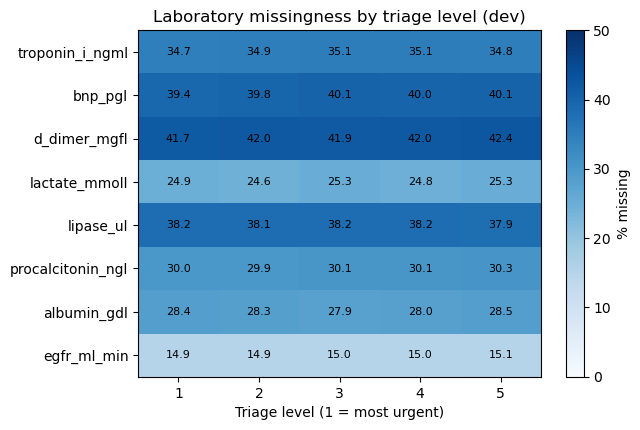

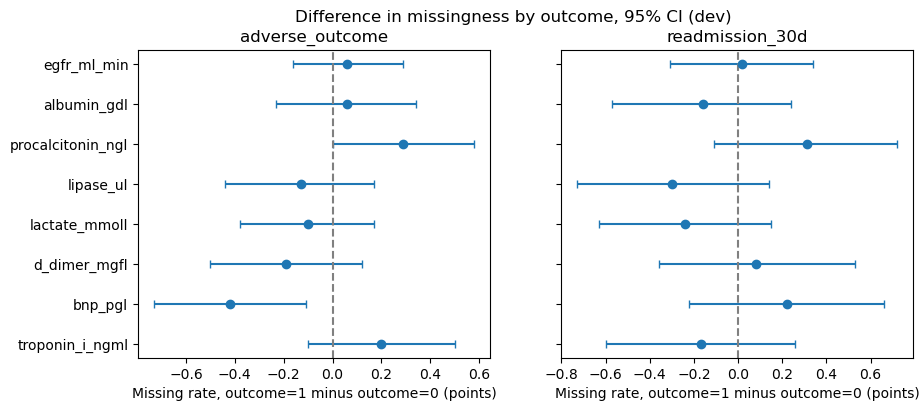

In [14]:
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

figs = Path("../reports/figures")
cols8 = lab7 + ["egfr_ml_min"]
miss = dev[cols8].isna()

# --- table: missing rate + outcome gap with 95% CI ---
rows = []
for c in cols8:
    m = miss[c]
    r = {"column": c,
         "pct_missing_dev": round(m.mean() * 100, 2),
         "pct_missing_val": round(val[c].isna().mean() * 100, 2)}
    for t in targets:
        m1, m0 = m[dev[t] == 1], m[dev[t] == 0]
        p1, p0 = m1.mean(), m0.mean()
        diff = (p1 - p0) * 100
        se = np.sqrt(p1 * (1 - p1) / len(m1) + p0 * (1 - p0) / len(m0)) * 100
        r[f"{t}_diff_pts"] = round(diff, 2)
        r[f"{t}_ci_low"] = round(diff - 1.96 * se, 2)
        r[f"{t}_ci_high"] = round(diff + 1.96 * se, 2)
        r[f"{t}_p"] = round(chi2_contingency(pd.crosstab(m, dev[t]))[1], 3)
    rows.append(r)

ms = pd.DataFrame(rows)
ms.to_csv("../reports/tables/missingness_summary.csv", index=False)
print(ms.to_string(index=False))

# --- figure 1: missing % by triage level (fixed scale so flatness is visible) ---
hm = (miss.groupby(dev["triage_level"]).mean().T * 100).round(1)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
im = ax.imshow(hm.values, cmap="Blues", vmin=0, vmax=50, aspect="auto")
ax.set_xticks(range(hm.shape[1]))
ax.set_xticklabels(hm.columns)
ax.set_yticks(range(hm.shape[0]))
ax.set_yticklabels(hm.index)
ax.set_xlabel("Triage level (1 = most urgent)")
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        ax.text(j, i, f"{hm.values[i, j]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, label="% missing")
ax.set_title("Laboratory missingness by triage level (dev)")
plt.savefig(figs / "missingness_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# --- figure 2: outcome gap in missing rate, with 95% CI ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
y = np.arange(len(ms))
for ax, t in zip(axes, targets):
    d = ms[f"{t}_diff_pts"]
    err = [d - ms[f"{t}_ci_low"], ms[f"{t}_ci_high"] - d]
    ax.errorbar(d, y, xerr=err, fmt="o", capsize=3)
    ax.axvline(0, color="grey", linestyle="--")
    ax.set_title(t)
    ax.set_xlabel("Missing rate, outcome=1 minus outcome=0 (points)")
axes[0].set_yticks(y)
axes[0].set_yticklabels(ms["column"])
fig.suptitle("Difference in missingness by outcome, 95% CI (dev)")
plt.savefig(figs / "missingness_by_outcome.png", dpi=150, bbox_inches="tight")
plt.show()

### Missingness by outcome (dev rows only, 95% CI)

Table: reports/tables/missingness_summary.csv. Figures: missingness_heatmap.png, missingness_by_outcome.png.

- Val missing rates match dev within 0.3 points for all eight columns.
- 16 comparisons (8 columns x 2 targets). Two have p < 0.05: bnp_pgl vs adverse_outcome (-0.42 points, 95% CI -0.73 to -0.11, p = 0.008) and procalcitonin_ngl vs adverse_outcome (+0.29 points, CI 0.00 to 0.58, p = 0.048). Neither passes a Bonferroni threshold of 0.003. About 0.8 hits are expected by chance at 16 tests. The two differences have opposite signs.
- Every difference is under half a percentage point, against missing rates of 15% to 42%.
- Conclusion: no evidence that missingness differs by outcome. This agrees with the earlier checks (flat by triage level, year and chief complaint; AUC 0.50 when predicting the flags).

adverse_outcome by age_band
age_band      0-9    10-19    20-29    30-39    40-49    50-59    60-69    70-79    80-89   90-99  100-109  110-119
mean         27.5     27.4     27.4     27.2     31.2     41.6     52.5     63.4     73.8    81.2     86.4     90.9
count     16107.0  22978.0  41056.0  59794.0  70808.0  69241.0  54711.0  35259.0  18605.0  7994.0   2772.0   1040.0

adverse_outcome by triage_level
triage_level        1        2         3         4        5
mean             86.4     67.6      46.4      31.6     24.3
count         11787.0  48311.0  120287.0  159738.0  60242.0

readmission_30d by age_band
age_band      0-9    10-19    20-29    30-39    40-49    50-59    60-69    70-79    80-89   90-99  100-109  110-119
mean         10.4     10.4     10.6     10.8     10.5     12.0     15.9     19.9     25.9    30.5     37.7     44.0
count     16107.0  22978.0  41056.0  59794.0  70808.0  69241.0  54711.0  35259.0  18605.0  7994.0   2772.0   1040.0

readmission_30d by charlson_cap
c

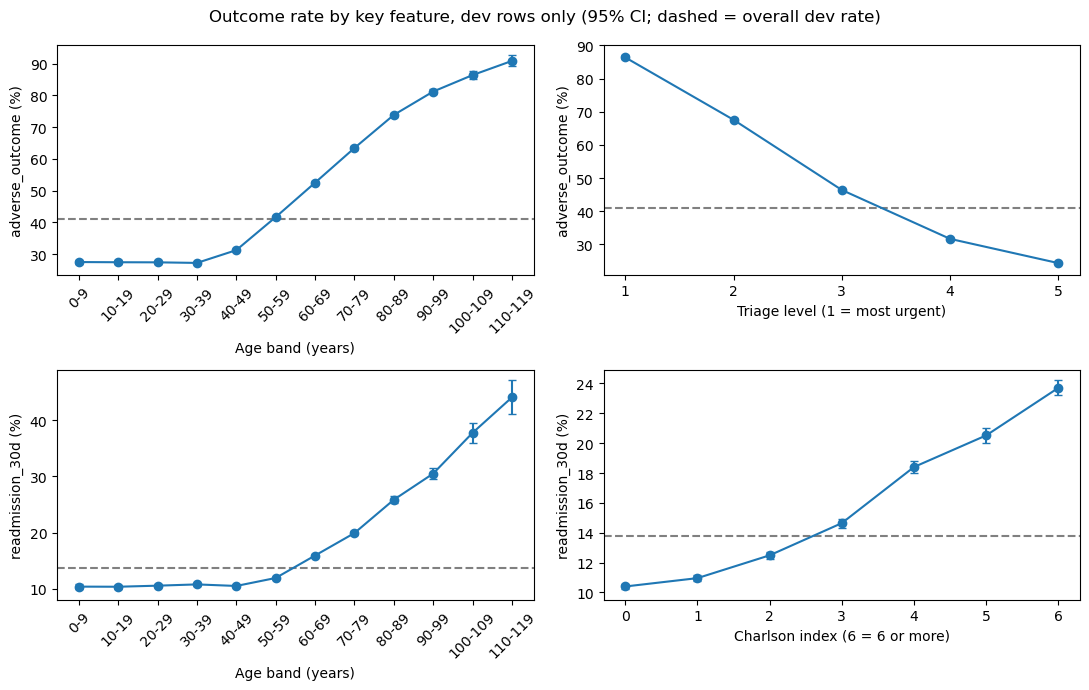

In [15]:
def rate_ci(d, by, t):
    g = d.groupby(by, observed=True)[t].agg(["mean", "count"])
    se = np.sqrt(g["mean"] * (1 - g["mean"]) / g["count"])
    g["lo"], g["hi"] = g["mean"] - 1.96 * se, g["mean"] + 1.96 * se
    return g

d = dev.copy()
edges = np.arange(0, 121, 10)
d["age_band"] = pd.cut(d["age"], bins=edges, right=False,
                       labels=[f"{a}-{a+9}" for a in edges[:-1]])
d["charlson_cap"] = d["charlson_comorbidity_index"].clip(upper=6)

panels = [("adverse_outcome", "age_band", "Age band (years)"),
          ("adverse_outcome", "triage_level", "Triage level (1 = most urgent)"),
          ("readmission_30d", "age_band", "Age band (years)"),
          ("readmission_30d", "charlson_cap", "Charlson index (6 = 6 or more)")]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (t, by, xlabel) in zip(axes.ravel(), panels):
    g = rate_ci(d, by, t)
    x = np.arange(len(g))
    ax.errorbar(x, g["mean"] * 100, yerr=[(g["mean"] - g["lo"]) * 100, (g["hi"] - g["mean"]) * 100],
                fmt="o-", capsize=3)
    ax.axhline(d[t].mean() * 100, color="grey", linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(g.index.astype(str), rotation=45 if by == "age_band" else 0)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"{t} (%)")
    print(t, "by", by)
    print((g[["mean", "count"]].assign(mean=lambda z: (z["mean"] * 100).round(1))).T.to_string())
    print()
fig.suptitle("Outcome rate by key feature, dev rows only (95% CI; dashed = overall dev rate)")
fig.tight_layout()
plt.savefig(figs / "outcome_rates_by_feature.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

adv_feats = [c for c in features if c != "covid_vaccinated"]
pool = pd.concat([dev, val])

def adv_auc(a, b, n=60_000, seed=42):
    a = a.sample(min(n, len(a)), random_state=seed)
    b = b.sample(min(n, len(b)), random_state=seed)
    X = pd.concat([a[adv_feats], b[adv_feats]], ignore_index=True)
    y = np.r_[np.zeros(len(a)), np.ones(len(b))]
    for c in X.select_dtypes(include=["object", "string"]).columns:
        X[c] = X[c].astype("category")
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)
    m = HistGradientBoostingClassifier(max_iter=100, random_state=seed,
                                       categorical_features="from_dtype").fit(Xtr, ytr)
    return round(roc_auc_score(yte, m.predict_proba(Xte)[:, 1]), 3)

yr = lambda *ys: pool[pool["arrival_year"].isin(ys)]
tests = {
    "2019 vs 2020 (pre-COVID vs peak)": (yr(2019), yr(2020)),
    "2019 vs 2021 (pre-COVID vs ongoing)": (yr(2019), yr(2021)),
    "2019 vs 2022 (pre-COVID vs post)": (yr(2019), yr(2022)),
    "dev 2019-2021 vs val 2022": (yr(2019, 2020, 2021), yr(2022)),
}
res = pd.DataFrame([(k, adv_auc(a, b)) for k, (a, b) in tests.items()],
                   columns=["comparison", "AUC (0.50 = no shift)"])
res.to_csv("../reports/tables/feature_drift_adversarial.csv", index=False)
print(res.to_string(index=False))

                         comparison  AUC (0.50 = no shift)
   2019 vs 2020 (pre-COVID vs peak)                  0.536
2019 vs 2021 (pre-COVID vs ongoing)                  0.495
   2019 vs 2022 (pre-COVID vs post)                  0.565
          dev 2019-2021 vs val 2022                  0.500


In [17]:
from scipy.stats import ks_2samp, chi2_contingency

a, b = yr(2019), yr(2022)
rows = []
for c in adv_feats:
    if a[c].dtype == "object":
        ct = pd.crosstab(pd.concat([a[c], b[c]]).values, np.r_[np.zeros(len(a)), np.ones(len(b))])
        rows.append((c, "Cramer V", round(float((chi2_contingency(ct)[0] / ct.values.sum()) ** 0.5), 4)))
    else:
        rows.append((c, "KS", round(float(ks_2samp(a[c].dropna(), b[c].dropna()).statistic), 4)))
drift = pd.DataFrame(rows, columns=["feature", "stat", "value"]).sort_values("value", ascending=False)
print(drift.head(10).to_string(index=False))
print()

def adv_auc_on(a, b, feats, n=60_000, seed=42):
    a = a.sample(min(n, len(a)), random_state=seed)
    b = b.sample(min(n, len(b)), random_state=seed)
    X = pd.concat([a[feats], b[feats]], ignore_index=True)
    y = np.r_[np.zeros(len(a)), np.ones(len(b))]
    for c in X.select_dtypes(include=["object", "string"]).columns:
        X[c] = X[c].astype("category")
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)
    m = HistGradientBoostingClassifier(max_iter=100, random_state=seed,
                                       categorical_features="from_dtype").fit(Xtr, ytr)
    return round(roc_auc_score(yte, m.predict_proba(Xte)[:, 1]), 3)

cal = ["arrival_month", "arrival_day", "arrival_day_of_week"]
print("Calendar columns only, 2019 vs 2022:", adv_auc_on(yr(2019), yr(2022), cal))
print("Calendar columns only, 2019 vs 2021:", adv_auc_on(yr(2019), yr(2021), cal))
print("All features minus calendar, 2019 vs 2022:",
      adv_auc_on(yr(2019), yr(2022), [c for c in adv_feats if c not in cal]))

            feature     stat  value
    chief_complaint Cramer V 0.0103
               city Cramer V 0.0090
       arrival_mode Cramer V 0.0060
arrival_day_of_week Cramer V 0.0059
    troponin_i_ngml       KS 0.0055
     potassium_meql       KS 0.0052
                age       KS 0.0050
          lipase_ul       KS 0.0050
       calcium_mgdl       KS 0.0049
          height_cm       KS 0.0044

Calendar columns only, 2019 vs 2022: 0.99
Calendar columns only, 2019 vs 2021: 0.99
All features minus calendar, 2019 vs 2022: 0.501


In [18]:
print("Month + weekday only, 2019 vs 2022:", adv_auc_on(yr(2019), yr(2022), ["arrival_month", "arrival_day_of_week"]))
print("Month + weekday only, 2019 vs 2021:", adv_auc_on(yr(2019), yr(2021), ["arrival_month", "arrival_day_of_week"]))
print("Day of month only,    2019 vs 2022:", adv_auc_on(yr(2019), yr(2022), ["arrival_day"]))

features = [c for c in features if c != "arrival_day"]
summary = summary[summary["feature"] != "arrival_day"]
summary.to_csv("../reports/tables/feature_summary.csv", index=False)
print("Features now:", len(features))

Month + weekday only, 2019 vs 2022: 0.553
Month + weekday only, 2019 vs 2021: 0.554
Day of month only,    2019 vs 2022: 0.497
Features now: 92


In [19]:
for c in ["arrival_month", "arrival_day_of_week", "arrival_hour"]:
    print(f"{c} alone, 2019 vs 2022:", adv_auc_on(yr(2019), yr(2022), [c]))
print()

def cramers_v(s, y):
    ct = pd.crosstab(s, y)
    chi2 = chi2_contingency(ct)[0]
    return round(float((chi2 / (ct.values.sum() * (min(ct.shape) - 1))) ** 0.5), 4)

rows = [(c, t, cramers_v(dev[c], dev[t]))
        for c in ["arrival_month", "arrival_day_of_week", "arrival_hour"] for t in targets]
print(pd.DataFrame(rows, columns=["feature", "target", "Cramer V"])
        .pivot(index="feature", columns="target", values="Cramer V"))

arrival_month alone, 2019 vs 2022: 0.501
arrival_day_of_week alone, 2019 vs 2022: 0.504
arrival_hour alone, 2019 vs 2022: 0.501

target               adverse_outcome  readmission_30d
feature                                              
arrival_day_of_week           0.0052           0.0022
arrival_hour                  0.0157           0.0075
arrival_month                 0.0048           0.0042


In [20]:
drop_calendar = ["arrival_month", "arrival_day_of_week"]
features = [c for c in features if c not in drop_calendar]
summary = summary[summary["feature"].isin(features)]
summary.to_csv("../reports/tables/feature_summary.csv", index=False)

assert "arrival_day" not in features
print("Features now:", len(features))
print(summary.groupby("group").size().to_dict())
print("Temporal features left:", summary.loc[summary["group"] == "temporal", "feature"].tolist())

Features now: 90
{'comorbidity': 19, 'demographic': 7, 'history': 3, 'institutional': 4, 'laboratory': 30, 'medication': 11, 'presentation': 3, 'temporal': 1, 'vitals': 12}
Temporal features left: ['arrival_hour']


## Feature drift across years (dev and val features only, holdout untouched)

Method: a gradient boosting model tries to tell one year from another using the features. AUC 0.50 means no shift. The random split inside this test is a diagnostic only, not model evaluation. Table: reports/tables/feature_drift_adversarial.csv (first four comparisons only).

- Dev (2019 to 2021) vs val (2022), 92 features: AUC 0.500. A model trained on dev does not face a covariate shift on val. covid_vaccinated was left out of this test because it is 0 for all of 2019 and 2020 by definition.
- The three calendar columns (month, day of month, weekday) together separate years at AUC 0.99. The generator follows the real calendar, so the combination fixes the date. Without them, 2019 vs 2022 drops to 0.501.
- Day of month alone: 0.497. Month, weekday and hour alone: 0.501 to 0.504. Month and weekday together: 0.553 (2019 vs 2022) and 0.554 (2019 vs 2021). Cause untested, probably the count of each weekday per month varying by year.
- Per-feature gaps between 2019 and 2022 are tiny (largest KS 0.0055, largest Cramer's V 0.010).
- An early all-feature test gave 0.495 for 2019 vs 2021 while the calendar alone gave 0.99 for the same pair. The large model underused the signal, so a single adversarial AUC can hide a year fingerprint.
- Kaggle describes structured distribution shift in 2020 and 2021. It is not visible in the allowed features. Excluded columns such as covid_tested were not tested.

## Final feature set (supersedes the "Feature set" section above)

Dropped from model features: arrival_day, arrival_month, arrival_day_of_week. Day of month has no clinical meaning and is the strongest year fingerprint. Month and weekday show no target signal (Cramer's V 0.002 to 0.005, at the noise floor for 400k rows) and contribute to the year fingerprint. They stay in the file for the season and weekend subgroup tables.

Kept: arrival_hour. Alone it shows no year shift (0.501). Cramer's V is 0.016 for adverse_outcome (small, about twice the noise floor) and 0.0075 for readmission_30d (at the floor).

**90 model features** (53 numeric, 30 binary, 7 categorical): laboratory 30, comorbidity 19, vitals 12, medication 11, demographic 7, institutional 4, history 3, presentation 3, temporal 1.

The official list is reports/tables/feature_summary.csv. data/interim/model_ready.parquet still contains the dropped calendar columns. Notebook 03 must read the feature list from the CSV, not from the parquet's column names.

## Outcome patterns (dev rows only, marginal rates)
- adverse_outcome: flat near 27% for ages 0 to 39, then rises to 41.6% (50 to 59), 63.4% (70 to 79) and 90.9% (age 110). By triage level: 86.4% at level 1, falling to 24.3% at level 5.
- readmission_30d: flat near 10.5% under age 50, then 15.9% (60 to 69), 25.9% (80 to 89) and 44.0% (age 110). By Charlson index: 10.4% at 0, 23.7% at 6 or more.
- Age is a hinge starting near 40 (adverse_outcome) and 50 (readmission_30d), not a straight line. Age appears capped at 110.
- Associations only, not causal claims.

## Limitations
- Missingness conclusions cover only the variables tested. True MNAR depends on the unseen lab value and cannot be tested from observed data.
- Single-feature AUC and Cramer's V miss interactions.
- All EDA decisions used dev rows (and val features for the drift check). Holdout features were never examined and holdout labels were removed from this notebook.

## Moves to Notebook 03
- Load data/interim/model_ready.parquet and the feature list from reports/tables/feature_summary.csv. Train on dev, select on val.
- Constant-prevalence baseline first, so PR-AUC is judged against 0.41 and 0.14.
- Missingness comparison: (1) imputation only, (2) imputation plus indicators for the seven labs, (3) native handling in boosted trees. No indicator for egfr_ml_min.
- No-labs ablation (drops all 30 lab columns). Expect readmission_30d to depend on labs very little.
- Logistic Regression: age bins or splines are required, because the age effect is a hinge.